In [1]:
import os
import sys
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Füge das Projekt-Hauptverzeichnis (zwei Ebenen höher: '../..') hinzu
sys.path.append(os.path.abspath(os.path.join('../..')))
sys.path.append(os.path.abspath(os.path.join('..')))  

# Jetzt über das "python"-Package importieren
from python.evaluation.metrics import calculate_pretreatment_fit, calculate_ground_truth_effect
from python.evaluation.visualization import plot_fit_joint_contour, plot_transport_comparison, plot_fit_copula, plot_fit_cdf, plot_fit_density, plot_fit_image
from python.tea import disco_tea

In [30]:
# load fits
dico_energy = joblib.load('results/fits/real_data/cps_energy.pkl')
dico_mixture = joblib.load('results/fits/real_data/medicaid_mixture.pkl')
dico_tangential = joblib.load('results/fits/real_data/cps_tangential.pkl')
dico_swasserstein = joblib.load('results/fits/real_data/medicaid_swasserstein.pkl')

In [3]:
for period in range(1, len(dico_tangential.results_periods)+1):
    dico_tangential.results_periods[period].DiSCo.samples[:,2:] = np.round(dico_tangential.results_periods[period].DiSCo.samples[:,2:])

for period in range(1, len(dico_swasserstein.results_periods)+1):
    dico_swasserstein.results_periods[period].DiSCo.samples[:,2:] = np.round(dico_swasserstein.results_periods[period].DiSCo.samples[:,2:])

In [4]:
pre_periods = [1,2,3,4,5,6, 7]
post_periods = [8,9,10,11]

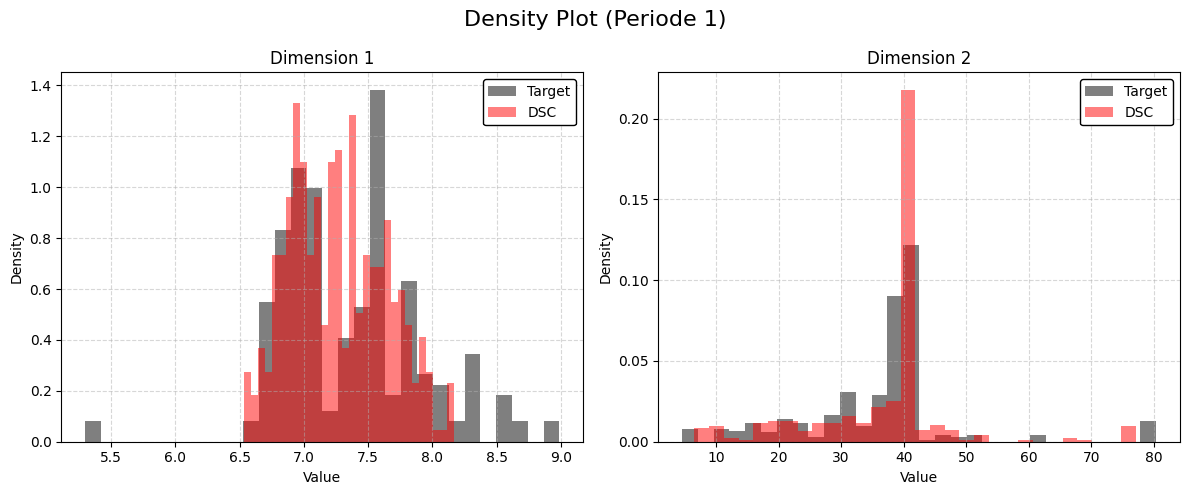

In [36]:
plot_fit_density(dico_tangential, period=1)

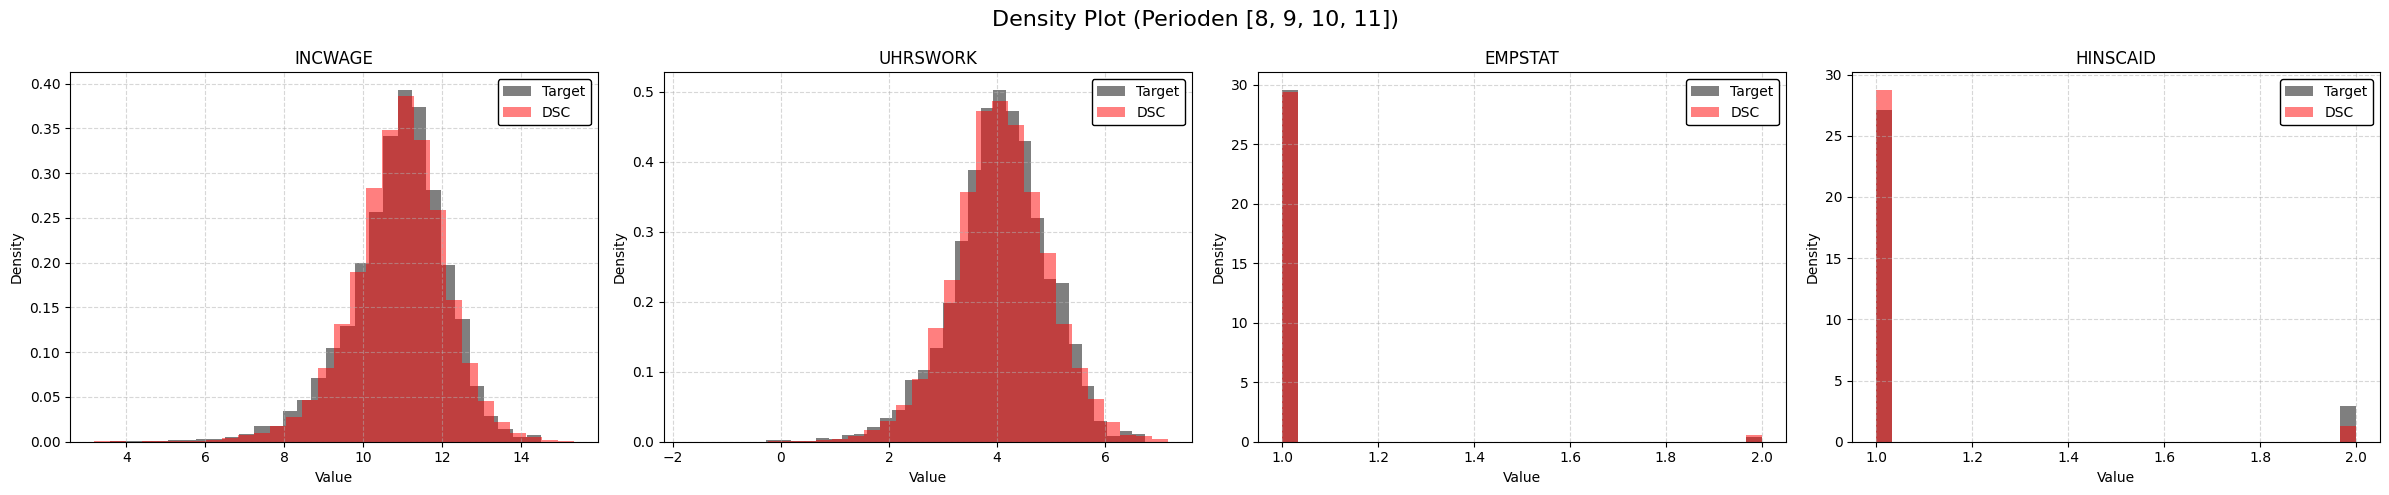

In [ ]:
plot_fit_density(dico_energy, period=[8,9,10,11], var_names=['INCWAGE', 'UHRSWORK','EMPSTAT','HINSCAID'])

In [7]:
result = dico_swasserstein

pre_sample = [result.results_periods[per].DiSCo.samples for per in pre_periods]
pre_sample = np.vstack(pre_sample)

pre_target = [result.results_periods[per].target.data for per in pre_periods]
pre_target = np.vstack(pre_target)

post_sample = [result.results_periods[per].DiSCo.samples for per in post_periods]
post_sample = np.vstack(post_sample)

post_target = [result.results_periods[per].target.data for per in post_periods]
post_target = np.vstack(post_target)

print('Variances Wage Pre')
print(f'Variance Conterfactual: {np.var(pre_sample[:,0])}')
print(f'Variance Actual: {np.var(pre_target[:,0])}')

print('\nVariances Wage Post')
print(f'Variance Conterfactual: {np.var(post_sample[:,0])}')
print(f'Variance Actual: {np.var(post_target[:,0])}')

print('\nVariances Hours Pre')
print(f'Variance Conterfactual: {np.var(pre_sample[:,1])}')
print(f'Variance Actual: {np.var(pre_target[:,1])}')

print('\nVariances Hours Post')
print(f'Variance Conterfactual: {np.var(post_sample[:,1])}')
print(f'Variance Actual: {np.var(post_target[:,1])}')

print('\nShare Employed Pre')
print(f'Share Conterfactual: {np.mean(pre_sample[:,2]-1)}')
print(f'Share Actual: {np.mean(pre_target[:,2]-1)}')

print('\nShare Employed Post')
print(f'Share Conterfactual: {np.mean(post_sample[:,2]-1)}')
print(f'Share Actual: {np.mean(post_target[:,2]-1)}')

print('\nShare Insured Pre')
print(f'Share Conterfactual: {np.mean(pre_sample[:,3]-1)}')
print(f'Share Actual: {np.mean(pre_target[:,3]-1)}')

print('\nShare Insured Post')
print(f'Share Conterfactual: {np.mean(post_sample[:,3]-1)}')
print(f'Share Actual: {np.mean(post_target[:,3]-1)}')


Variances Wage Pre
Variance Conterfactual: 1.428825855255127
Variance Actual: 1.517953634262085

Variances Wage Post
Variance Conterfactual: 1.46256685256958
Variance Actual: 1.5112576484680176

Variances Hours Pre
Variance Conterfactual: 0.7108358144760132
Variance Actual: 0.7636317014694214

Variances Hours Post
Variance Conterfactual: 0.7767087817192078
Variance Actual: 0.791555643081665

Share Employed Pre
Share Conterfactual: 0.027142856270074844
Share Actual: 0.028214285150170326

Share Employed Post
Share Conterfactual: 0.01899999938905239
Share Actual: 0.014000000432133675

Share Insured Pre
Share Conterfactual: 0.03742857277393341
Share Actual: 0.03557142987847328

Share Insured Post
Share Conterfactual: 0.04149999842047691
Share Actual: 0.09737499803304672


In [8]:
medicaid_df = pd.read_csv('data/datasets/medicaid.csv')

In [9]:
def weighted_variance(values, weights):
    weighted_mean = np.average(values, weights=weights)
    weighted_var = np.average((values - weighted_mean)**2, weights=weights)
    return weighted_var

In [10]:
medicaid_df_pre = medicaid_df[medicaid_df['YEAR'] < 2017]
medicaid_df_post = medicaid_df[medicaid_df['YEAR'] >= 2017]

medicaid_df_post_target = medicaid_df_post[medicaid_df_post['STATEFIP'] == 30]

In [11]:
print(weighted_variance(medicaid_df_post_target['INCWAGE'], medicaid_df_post_target['PERWT']))

1.5062152272935925


In [12]:
print(weighted_variance(medicaid_df_post_target['UHRSWORK'], medicaid_df_post_target['PERWT']))

0.787978107728865


In [13]:
np.average(medicaid_df_post_target['HINSCAID'], weights=medicaid_df_post_target['PERWT'])

np.float64(1.0968447567759627)

In [14]:
plot_fit_joint_contour(dico_energy, period=2)

Joint Contour Plot wird nur für 2D Daten unterstützt.


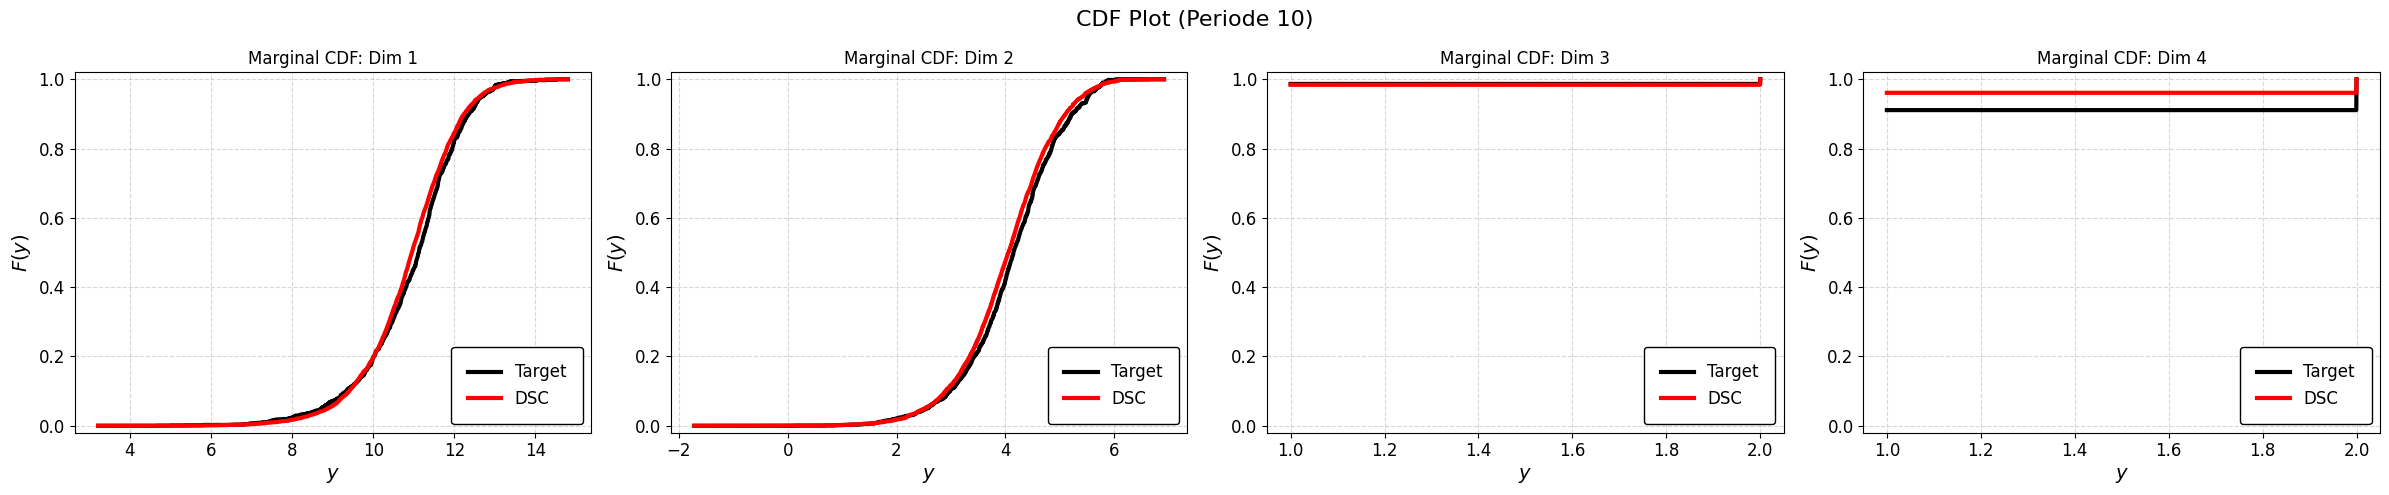

In [15]:
plot_fit_cdf(dico_energy, period=10)

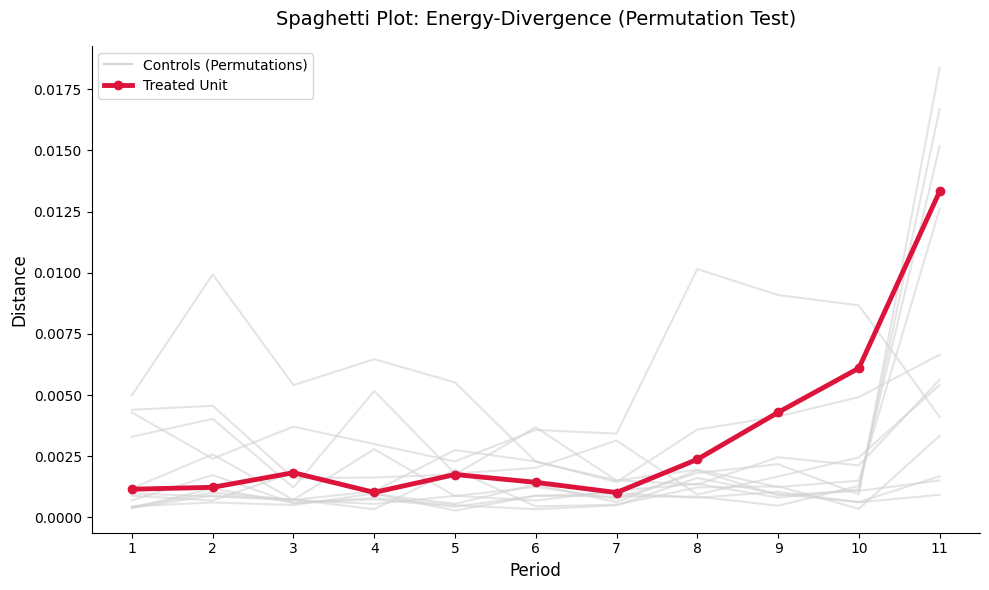

0.3076923076923077
0.07692307692307693


In [16]:
import matplotlib.pyplot as plt
import numpy as np
model = dico_energy

dist_p = model.perm.distp
dist_t = model.perm.distt
periods = np.arange(1, len(dist_t) + 1)

plt.figure(figsize=(10, 6), dpi=100)

# 1. Alle Controls auf einmal plotten (dist_p.T zeichnet jede Spalte als eigene Linie)
plt.plot(periods, dist_p.T, color="lightgray", alpha=0.6, linewidth=1.5)

# 2. Dummy-Eintrag für die Legende (damit "Controls" nur 1x auftaucht)
plt.plot([], [], color="lightgray", linewidth=1.5, label="Controls (Permutations)")

# 3. Treated Unit (Target) plotten
plt.plot(periods, dist_t, color="crimson", linewidth=3.5, marker="o", label="Treated Unit")

# Styling & Beschriftung
plt.title("Spaghetti Plot: Energy-Divergence (Permutation Test)", fontsize=14, pad=15)
plt.xlabel("Period", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.xticks(periods)
plt.legend(loc="upper left")

# Cleanes Design (entspricht sns.despine)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(model.perm.p_overall)
print(1/(model.perm.J_1+1))

In [23]:

# Beispiel 1: Mit festen Grenzen (bounds) für jede Dimension
# (Z.B. Dim 1: log-Lohn zwischen 1.5 und 2.5, Dim 2: Arbeitsstunden zwischen 35 und 45)
# Die Anzahl der Tupel muss deiner Anzahl an Dimensionen (Y-Variablen) entsprechen!
res_bounds = disco_tea(
    disco=dico_energy,            # Dein geladenes DiSCo Modell (z.B. dico_energy)
    agg="prob_mass", 
    graph=True,             # Erstellt automatisch einen Plot über die Zeit
    bounds=[(-np.inf, 100), (-np.inf, 100), (1, 2) ,(1,1)] 
)

# Der berechnete Treatment-Effekt pro Periode:
for period in res_bounds.treats.keys():
    print(f"Time: {period}  Effect: {res_bounds.treats[period]['mass_diff']:.4f}")

Time: 2010  Effect: 0.0088
Time: 2011  Effect: 0.0019
Time: 2012  Effect: 0.0134
Time: 2013  Effect: 0.0171
Time: 2014  Effect: -0.0098
Time: 2015  Effect: 0.0197
Time: 2016  Effect: -0.0238
Time: 2017  Effect: -0.0528
Time: 2018  Effect: -0.0632
Time: 2019  Effect: -0.0479
Time: 2020  Effect: -0.0598


In [20]:
import copy
dico_test = copy.deepcopy(dico_energy)
dico_test.weights = np.array(
    [
        0.184,
        0.0,
        0.0,
        0.0,
        0.174,
        0.0,
        0.01,
        0.513,
        0.0,
        0.0,
        0.119,
        0.0
    ]
)
np.round(dico_energy.weights, decimals=3)

array([0.056, 0.   , 0.   , 0.051, 0.251, 0.   , 0.078, 0.33 , 0.043,
       0.008, 0.11 , 0.073])

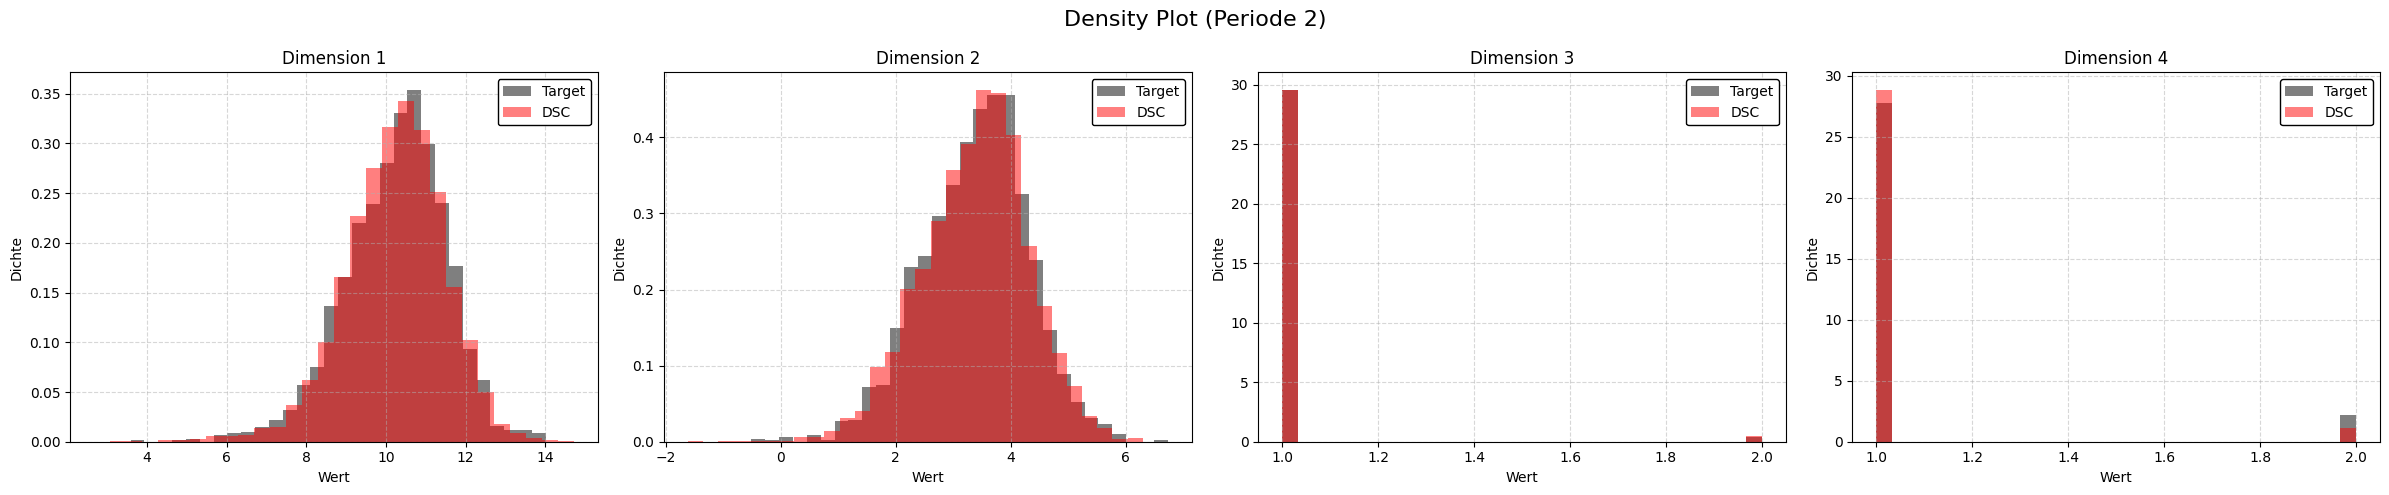

In [17]:
plot_fit_density(dico_tangential, period=2)

In [15]:
pd.Series(dico_test.weights, index = dico_test.control_ids)

1     0.184
12    0.000
13    0.000
20    0.000
28    0.174
37    0.000
45    0.010
46    0.513
47    0.000
48    0.000
55    0.119
56    0.000
dtype: float64

In [7]:
effect_energy = joblib.load('results/effects/medicaid_30_2017_energy_teas.pkl')


# Hybrid: Weigths hitrates

In [66]:
from data import get_hybrid_data

weigths = []

for seed in range(25):
    weigths.append(get_hybrid_data('data/datasets/medicaid.csv', seed=seed)[1])

KeyboardInterrupt: 

In [45]:
method = 'swasserstein'

fitted_weigths_swasserstein = []

for mc in range(25):
    result = joblib.load(f'results/fits/mc_hybrid/medi_hybrid_30_2017_{method}_mc{mc}.pkl')
    result_weights = result.weights
    result_ids = result.control_ids 
    fitted_weigths_swasserstein.append({result_id: weight for result_id, weight in zip(result_ids,result_weights )})

method = 'tangential'

fitted_weigths_tangential = []

for mc in range(25):
    result = joblib.load(f'results/fits/mc_hybrid/medi_hybrid_30_2017_{method}_mc{mc}.pkl')
    result_weights = result.weights
    result_ids = result.control_ids 
    fitted_weigths_tangential.append({result_id: weight for result_id, weight in zip(result_ids,result_weights )})

method = 'mixture'

fitted_weigths_mixture = []

for mc in range(25):
    result = joblib.load(f'results/fits/mc_hybrid/medi_hybrid_30_2017_{method}_mc{mc}.pkl')
    result_weights = result.weights
    result_ids = result.control_ids 
    fitted_weigths_mixture.append({result_id: weight for result_id, weight in zip(result_ids,result_weights )})

method = 'energy'

fitted_weigths_energy = []

for mc in range(25):
    result = joblib.load(f'results/fits/mc_hybrid/medi_hybrid_30_2017_{method}_mc{mc}.pkl')
    result_weights = result.weights
    result_ids = result.control_ids 
    fitted_weigths_energy.append({result_id: weight for result_id, weight in zip(result_ids,result_weights )})

df_swasserstein = pd.DataFrame(fitted_weigths_swasserstein)
df_tangential = pd.DataFrame(fitted_weigths_tangential)
df_mixture = pd.DataFrame(fitted_weigths_mixture)
df_energy = pd.DataFrame(fitted_weigths_energy)

=== Sparsity Vergleich (Methode: energy) ===
Durchschnittliche Anzahl echter Spender (w > 0.001): 5.0
Durchschnittliche Anzahl geschätzter Spender (w > 0.001): 12.5



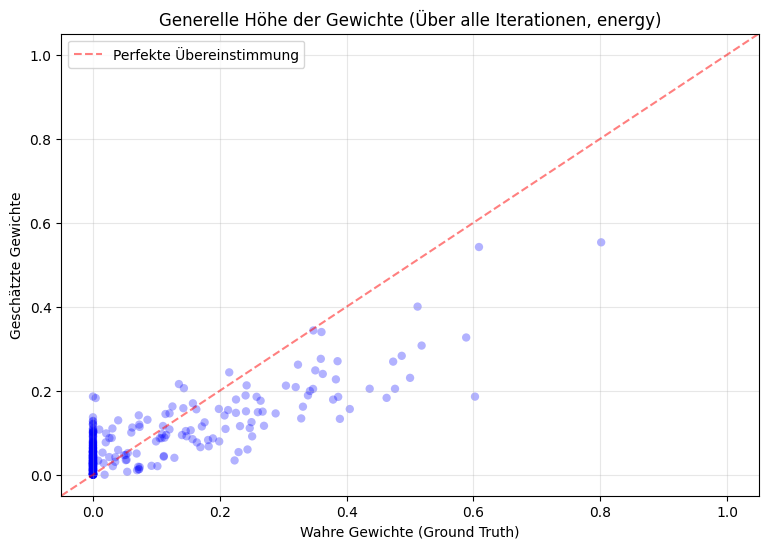

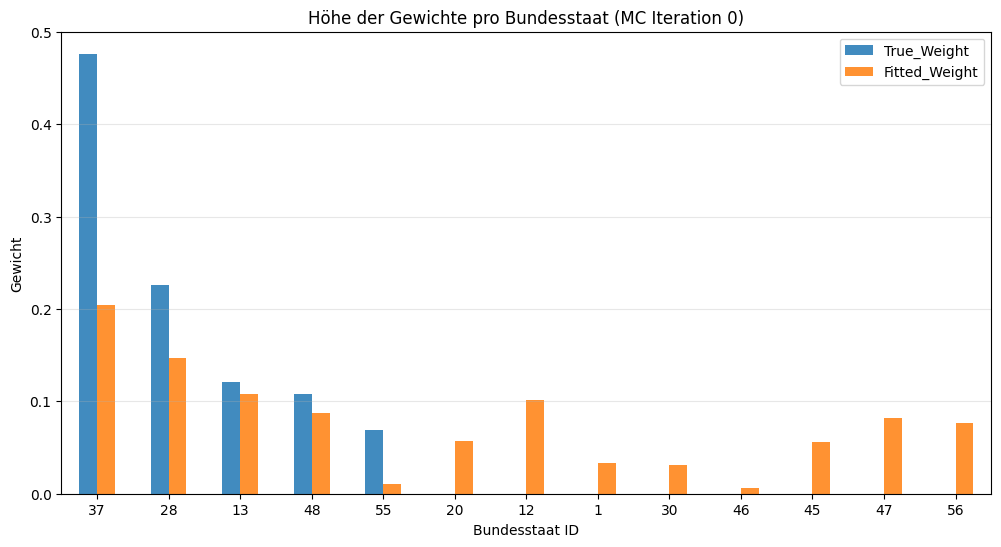

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

fitted_weigths = fitted_weigths_energy

# Schwellenwert für Sparsity
threshold = 1e-3

true_non_zeros_list = []
fitted_non_zeros_list = []

all_true_weights = []
all_fitted_weights = []

# 1. Iteriere über alle 25 MC Durchläufe aus deinen geladenen Listen
for mc in range(len(weigths)):
    true_dict = weigths[mc]
    fitted_dict = fitted_weigths[mc]
    
    mc_true_w = []
    mc_fitted_w = []
    
    # State-IDs aus den wahren Gewichten abrufen
    for state_id in true_dict.keys():
        t_w = true_dict.get(state_id, 0.0)
        f_w = fitted_dict.get(state_id, 0.0)
        
        mc_true_w.append(t_w)
        mc_fitted_w.append(f_w)
        
        all_true_weights.append(t_w)
        all_fitted_weights.append(f_w)
        
    true_non_zeros_list.append(sum(w > threshold for w in mc_true_w))
    fitted_non_zeros_list.append(sum(w > threshold for w in mc_fitted_w))

# 2. Sparsity Analyse (Durchschnitt über alle MC Iterationen)
avg_true_sparsity = np.mean(true_non_zeros_list)
avg_fitted_sparsity = np.mean(fitted_non_zeros_list)

print(f"=== Sparsity Vergleich (Methode: {method}) ===")
print(f"Durchschnittliche Anzahl echter Spender (w > {threshold}): {avg_true_sparsity:.1f}")
print(f"Durchschnittliche Anzahl geschätzter Spender (w > {threshold}): {avg_fitted_sparsity:.1f}\n")

# 3. Visualisierung: Original vs Neuer Fit (Generelle Höhe)
plt.figure(figsize=(9, 6))
# 45-Grad-Linie (Perfekter Match)
plt.plot([-0.05, 1.05], [-0.05, 1.05], 'r--', alpha=0.5, label='Perfekte Übereinstimmung')

# Wir plotten alle Gewichte aus allen Iterationen
plt.scatter(all_true_weights, all_fitted_weights, alpha=0.3, color='b', edgecolor='none')

plt.title(f'Generelle Höhe der Gewichte (Über alle Iterationen, {method})')
plt.xlabel('Wahre Gewichte (Ground Truth)')
plt.ylabel('Geschätzte Gewichte')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4. Barplot für EINE zufällige Iteration (z.B. Iteration 0), um es sich konkret anzusehen
mc_plot = 0
df_single_mc = pd.DataFrame({
    'State_ID': list(weigths[mc_plot].keys()),
    'True_Weight': [weigths[mc_plot].get(k, 0.0) for k in weigths[mc_plot].keys()],
    'Fitted_Weight': [fitted_weigths[mc_plot].get(k, 0.0) for k in weigths[mc_plot].keys()]
})

# Nur relevante Spender filtern
df_filtered = df_single_mc[(df_single_mc['True_Weight'] > threshold) | (df_single_mc['Fitted_Weight'] > threshold)].copy()
df_filtered.sort_values(by='True_Weight', ascending=False, inplace=True)

df_filtered.plot(x='State_ID', y=['True_Weight', 'Fitted_Weight'], kind='bar', figsize=(12, 6), alpha=0.85)
plt.title(f'Höhe der Gewichte pro Bundesstaat (MC Iteration {mc_plot})')
plt.ylabel('Gewicht')
plt.xlabel('Bundesstaat ID')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3) 
plt.legend()
plt.show()


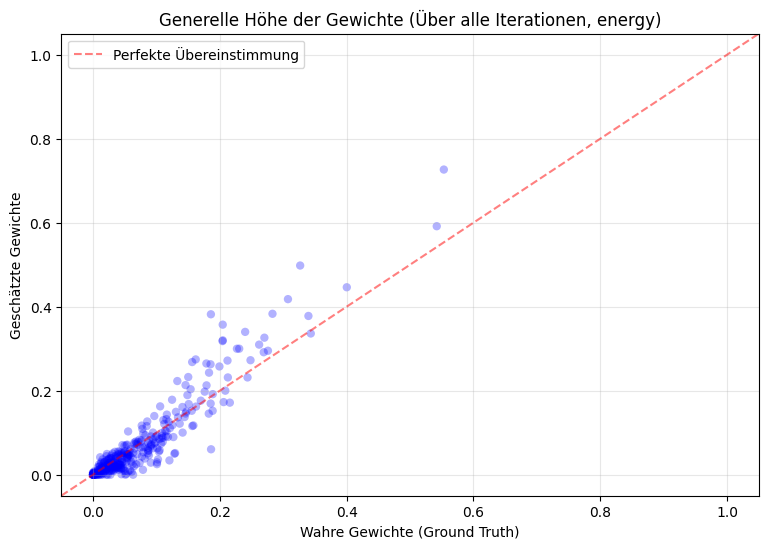

In [49]:
# 3. Visualisierung: Original vs Neuer Fit (Generelle Höhe)
plt.figure(figsize=(9, 6))
# 45-Grad-Linie (Perfekter Match)
plt.plot([-0.05, 1.05], [-0.05, 1.05], 'r--', alpha=0.5, label='Perfekte Übereinstimmung')

# Wir plotten alle Gewichte aus allen Iterationen
plt.scatter(np.reshape(df_energy.values, (1,-1))
            , np.reshape(df_mixture.values, (1,-1)),
             alpha=0.3, color='b', edgecolor='none')

plt.title(f'Generelle Höhe der Gewichte (Über alle Iterationen, {method})')
plt.xlabel('Wahre Gewichte (Ground Truth)')
plt.ylabel('Geschätzte Gewichte')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()